# top

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

notebook_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(notebook_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
print(sys.path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

%load_ext autoreload
%autoreload 2

['/mnt/ceph/users/blyo1/projects', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python310.zip', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10', '/mnt/sw/nix/store/71ksmx7k6xy3v9ksfkv5mp5kxxp64pd6-python-3.10.13-view/lib/python3.10/lib-dynload', '', '/mnt/home/blyo1/venvs/py310/lib/python3.10/site-packages']


# load vae model

In [ ]:
from b_models.vae.vae_inference import VAE_Inference
from b_models.vae.vae_lightning import VAE_Lightning
from b_models.configs.vae_config import SelectConfig
from utils.model_init import init_vae
from utils.wandb_utils import get_artifact

project_name = "vae_cis"
model_num = 13
artifact_id = "v39" 

# construct config from wandb run
model_path, artifact, config, run_config = get_artifact(model_num=model_num, artifact_id=artifact_id, project_name=project_name)
config = SelectConfig.from_dict(run_config)

vae = init_vae(config)
vae_lightning = VAE_Lightning.load_from_checkpoint(model_path, config=config).model
vae_inference = VAE_Inference(config).to(device)
vae_inference.load_state_dict(vae_lightning.state_dict()) 

/mnt/home/blyo1/hdiva/c_training/lightning_checkpoints/vae_cis
wandb run name: uceqqhdd


wandb:   1 of 1 files downloaded.  


<All keys matched successfully>

In [57]:
from a_datasets.circle_in_square.data import load_cis_data

cpu_tensor, (x, y) = load_cis_data(num_images=1000, img_size=config.image_dim)
print(cpu_tensor.shape)
print(cpu_tensor.min(), cpu_tensor.max())
# print(x, y)

# print(config.dataset_size)

torch.Size([1000, 1, 64, 64])
tensor(0.) tensor(1.)


In [58]:
config.train_batch_size_per_gpu

512

In [59]:
from torchvision import transforms

from a_datasets.custom_dataset_classes import CustomTensorDataset

transform = transforms.Compose(
    [
        transforms.Normalize((0.5,), (0.5,)),
    ]
)
train_dataset = CustomTensorDataset(cpu_tensor, transform)

input_img = train_dataset[31]
print(input_img.shape)
print(input_img.min())
print(input_img.max())


torch.Size([1, 64, 64])
tensor(-1.)
tensor(1.)


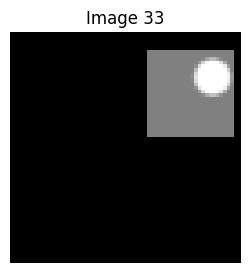

-1.0 1.0
---
-1.0 1.0


In [60]:
from utils.base_utils import t2n, to_01

"""select an image from bump dataset"""
img_idx = 33
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(target_img, cmap='gray', vmin=-1, vmax=1)
ax.axis('off')
ax.set_title(f"Image {img_idx}")
plt.show()

print(train_dataset[img_idx].min().item(), train_dataset[img_idx].max().item())
print('---')
print(target_img.min(), target_img.max())

In [61]:
config.hidden_channels

[128, 128, 128]

In [62]:
"""generate images from diva_inference"""
target_img = train_dataset[img_idx].unsqueeze(0).to(device)
# target_img = to_01(target_img)
print(target_img.min())
print(target_img.shape)
gen_img = vae_inference.conditional_sample(target_image_input=target_img)
print(gen_img.shape)
print(gen_img.min().item(), gen_img.max().item())

tensor(-1., device='cuda:0')
torch.Size([1, 1, 64, 64])
torch.Size([1, 1, 64, 64])
-1.2666243314743042 1.0200648307800293


(64, 64, 1)
(1, 64, 64, 1)
-0.13331217 1.0100324


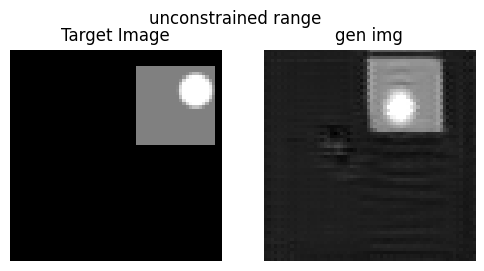

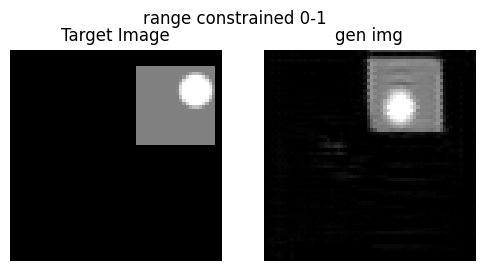

In [63]:
# figure
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))
target_img = to_01(target_img)
print(target_img.shape)

gen_img_np = t2n(gen_img)
gen_img_np = np.transpose(gen_img_np, (0,2,3,1))
gen_img_np = to_01(gen_img_np)
print(gen_img_np.shape)
print(gen_img_np.min(), gen_img_np.max())


fig, ax = plt.subplots(1,2, figsize=(6,3))
ax[0].imshow(target_img, vmin=0, vmax=1, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Target Image')
ax[1].imshow(gen_img_np[0], cmap='gray')
ax[1].axis('off')
ax[1].set_title('gen img')
fig.suptitle('unconstrained range')
plt.show()

fig, ax = plt.subplots(1,2, figsize=(6,3))
ax[0].imshow(target_img, vmin=0, vmax=1, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Target Image')
ax[1].imshow(gen_img_np[0], vmin=0, vmax=1, cmap='gray')
# ax[i].imshow(gen_img_np[i-1], cmap='gray')
ax[1].axis('off')
ax[1].set_title('gen img')
fig.suptitle('range constrained 0-1')
# fig.tight_layout()
plt.show()
# ax[1].axis('off')
# ax[1].set_title('Generated Image')

In [64]:
# mse calculation
print(config.image_dim)
mse = vae_inference.compute_loss(train_dataset[0:512].to(device))[1].item()
print(mse)

64
0.0043778554536402225


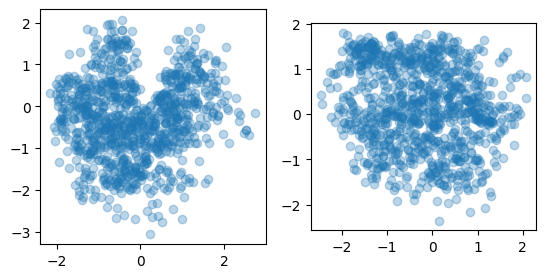

In [65]:
# encoder values
num_samples = 1000
latents = np.empty((num_samples, 4))
# gt_positions = np.empty((num_samples, 2))

for i in range(num_samples):
    target_img = train_dataset[i]
    # print(target_img.shape)
    z = vae_inference.encode(target_img.unsqueeze(0).to(device))[0].detach().cpu().numpy()
    latents[i] = z

fig, ax = plt.subplots(1, 2)
ax[0].scatter(*latents[:, :2].T, alpha=.3)
ax[0].set_aspect('equal')
ax[1].scatter(*latents[:, 2:].T, alpha=.3)
ax[1].set_aspect('equal')

plt.show()

In [66]:
# conditional sample
z = torch.randn(1, 4).to(device)
gen_img = vae_inference.conditional_sample_from_z(z)
print(gen_img.shape)

torch.Size([1, 1, 64, 64])


(1, 64, 64, 1)
-0.14406782 1.0113132


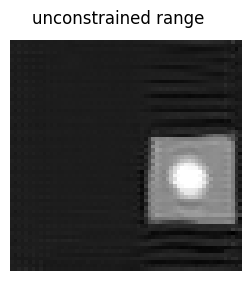

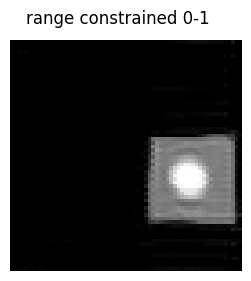

In [67]:
gen_img_np = t2n(gen_img)
gen_img_np = np.transpose(gen_img_np, (0,2,3,1))
gen_img_np = to_01(gen_img_np)
print(gen_img_np.shape)
print(gen_img_np.min(), gen_img_np.max())


fig, ax = plt.subplots(1,1, figsize=(6,3))
ax.imshow(gen_img_np.squeeze(), cmap='gray')
ax.axis('off')
# ax.set_title('gen img')
fig.suptitle('unconstrained range')
plt.show()

fig, ax = plt.subplots(1,1, figsize=(6,3))
ax.imshow(gen_img_np.squeeze(), vmin=0, vmax=1, cmap='gray')
ax.axis('off')
# ax.set_title('gen img')
fig.suptitle('range constrained 0-1')
plt.show()

# load ddpm

In [177]:
from b_models.ddpm.ddpm_inference import DDPM_Inference
from b_models.ddpm.ddpm_lightning import DDPM_Lightning
from b_models.configs.sami_config import SelectConfig
from utils.model_init import init_ddpm_model
from utils.wandb_utils import get_artifact

project_name = "ddpm_cis"
model_num = 16
artifact_id = "v9" 

# construct config from wandb run
model_path, artifact, config, run_config = get_artifact(model_num=model_num, project_name=project_name)
config = SelectConfig.from_dict(run_config)

ddpm = init_ddpm_model(config)
ddpm_lightning = DDPM_Lightning.load_from_checkpoint(model_path, config=config).model
ddpm_inference = DDPM_Inference(ddpm_lightning, config).to(device)

/mnt/home/blyo1/hdiva/c_training/lightning_checkpoints/ddpm_cis
wandb run name: fhwc2wqp


wandb:   1 of 1 files downloaded.  


In [178]:
from a_datasets.circle_in_square.data import load_cis_data

cpu_tensor, (square_targets, circle_targets) = load_cis_data(num_images=1000, img_size=config.image_dim)
print(cpu_tensor.shape)
print(cpu_tensor.min(), cpu_tensor.max())
print(square_targets.shape, circle_targets.shape)

# print(config.dataset_size)

torch.Size([1000, 1, 64, 64])
tensor(0.) tensor(1.)
torch.Size([1000, 2]) torch.Size([1000, 2])


In [179]:
config.train_batch_size_per_gpu

512

In [180]:
from torchvision import transforms

from a_datasets.custom_dataset_classes import CustomTensorDataset

transform = transforms.Compose(
    [
        transforms.Normalize((0.5,), (0.5,)),
    ]
)
train_dataset = CustomTensorDataset(cpu_tensor, transform)

input_img = train_dataset[31]
print(input_img.shape)
print(input_img.min())
print(input_img.max())


torch.Size([1, 64, 64])
tensor(-1.)
tensor(1.)


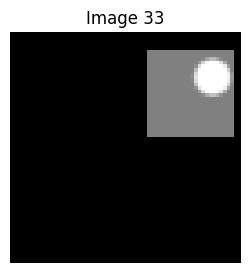

-1.0 1.0
---
-1.0 1.0


In [181]:
from utils.base_utils import t2n, to_01

"""select an image from cis dataset"""
img_idx = 33
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(target_img, cmap='gray', vmin=-1, vmax=1)
ax.axis('off')
ax.set_title(f"Image {img_idx}")
plt.show()

print(train_dataset[img_idx].min().item(), train_dataset[img_idx].max().item())
print('---')
print(target_img.min(), target_img.max())

In [182]:
"""generate images from sami_inference"""
ddpm_inference.unconditional_sample(N=4)
gen_img = ddpm_inference.x_t
print(gen_img.shape)
print(gen_img.min(), gen_img.max())

torch.Size([4, 1, 64, 64])
tensor(-1.0377, device='cuda:0') tensor(1.0903, device='cuda:0')


(64, 64, 1)
(4, 64, 64, 1)
-0.018866599 1.0451448


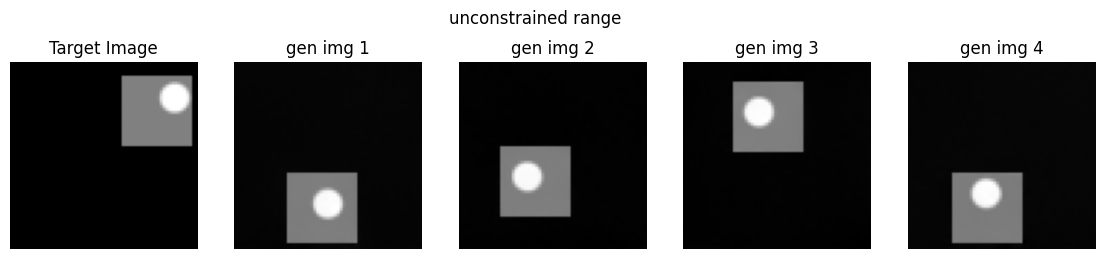

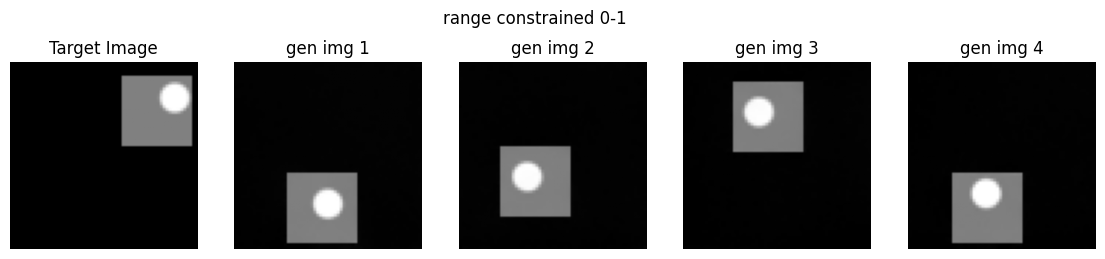

In [183]:
# figure
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))
target_img = to_01(target_img)
print(target_img.shape)

gen_img_np = t2n(gen_img)
gen_img_np = np.transpose(gen_img_np, (0,2,3,1))
gen_img_np = to_01(gen_img_np)
print(gen_img_np.shape)
print(gen_img_np.min(), gen_img_np.max())


fig, ax = plt.subplots(1,5, figsize=(14,3))
ax[0].imshow(target_img, vmin=0, vmax=1, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Target Image')
for i in range(1,5):
    # ax[i].imshow(gen_img_np[i-1], vmin=0, vmax=1, cmap='gray')
    ax[i].imshow(gen_img_np[i-1], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'gen img {i}')
fig.suptitle('unconstrained range')
plt.show()

fig, ax = plt.subplots(1,5, figsize=(14,3))
ax[0].imshow(target_img, vmin=0, vmax=1, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Target Image')
for i in range(1,5):
    ax[i].imshow(gen_img_np[i-1], vmin=0, vmax=1, cmap='gray')
    # ax[i].imshow(gen_img_np[i-1], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'gen img {i}')
fig.suptitle('range constrained 0-1')
# fig.tight_layout()
plt.show()
# ax[1].axis('off')
# ax[1].set_title('Generated Image')

## one step denoising

min tensor(-1., device='cuda:0') max tensor(1., device='cuda:0')
shape torch.Size([1, 1, 64, 64])
device cuda:0
(64, 64)


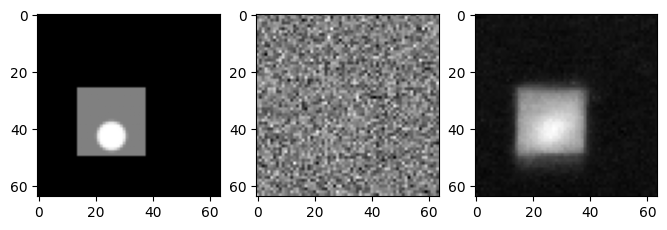

In [185]:
from utils.base_utils import check_input

img_idx = 59
input_image = train_dataset[img_idx].unsqueeze(0).to(device)
check_input(input_image)
t = 90
x0_hat, noisy_x = ddpm_inference.add_noise_and_denoise(input_image, t=t)
input_image = input_image.squeeze().cpu()
noisy_x = noisy_x.squeeze().detach().cpu().numpy()
x0_hat = x0_hat.squeeze().detach().cpu().numpy()
print(x0_hat.shape)

fig, ax = plt.subplots(1, 3, figsize=(8, 4))
ax[0].imshow(input_image, cmap="grey")
ax[1].imshow(noisy_x, cmap="grey")
ax[2].imshow(x0_hat, cmap="grey")

In [186]:
from tqdm import tqdm

# plot one shot denoising mse as a function of noise level
img_idxs = [1, 2, 3, 4, 5]
all_mses_ = np.empty((len(img_idxs), config.num_timesteps))
for j, img_idx in tqdm(enumerate(img_idxs)):
    input_image = train_dataset[img_idx].unsqueeze(0).to(device)
    for i in range(1, config.num_timesteps):
        x0_hat, _ = ddpm_inference.add_noise_and_denoise(input_image, t=i)
        input_image_cpu = input_image.squeeze().cpu()
        x0_hat_cpu = x0_hat.squeeze().detach().cpu()
        mse = F.mse_loss(x0_hat_cpu, input_image_cpu).item()
        all_mses_[j, i] = mse

5it [00:01,  3.70it/s]


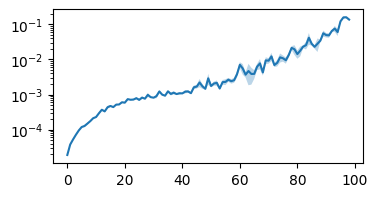

In [187]:
fig, ax = plt.subplots(1, 1, figsize=(4, 2))

all_mses = all_mses_[:, 1:]
mean = all_mses[1:].mean(axis=0)
sem = all_mses.std(axis=0) / np.sqrt(all_mses.shape[0])
x = np.arange(len(mean))

ax.plot(x, mean)
ax.fill_between(x, mean-sem, mean+sem, alpha=.3)
ax.set_yscale('log')

# load sami model

In [2]:
from b_models.sami.sami_inference import SAMI_Inference
from b_models.sami.sami_lightning import SAMI_Lightning
from b_models.configs.sami_config import (
    SAMI_CIS_28_Training_Config,
    SAMI_CIS_Training_Config,
    SAMI_SOS_Training_Config,
    SelectConfig,
)
from utils.model_init import init_sami_model
from utils.wandb_utils import get_artifact

project_name = "sami_sos"
# model_num = 21
# artifact_id = "v16" 
model_num = 29
artifact_id = "latest"

# construct config from wandb run
model_path, artifact, config, run_config = get_artifact(model_num=model_num, project_name=project_name)
if run_config['image_dim'] == 28:
    config = SAMI_CIS_28_Training_Config.from_dict(run_config)
else:
    config = SAMI_CIS_Training_Config.from_dict(run_config)

# config.noise_schedule = "reverse_linear_in_alpha_bar"
sami = init_sami_model(config)
sami_lightning = SAMI_Lightning.load_from_checkpoint(model_path, config=config).model
sami_inference = SAMI_Inference(sami_lightning, config).to(device)

KeyboardInterrupt: 

In [51]:
from a_datasets.circle_in_square.data import load_cis_data

cpu_tensor, (square_targets, circle_targets) = load_cis_data(num_images=1000, img_size=config.image_dim)
print(cpu_tensor.shape)
print(cpu_tensor.min(), cpu_tensor.max())
print(square_targets.shape, circle_targets.shape)

# print(config.dataset_size)

torch.Size([1000, 1, 28, 28])
tensor(0.) tensor(1.)
torch.Size([1000, 2]) torch.Size([1000, 2])


In [52]:
from torchvision import transforms

from a_datasets.custom_dataset_classes import CustomTensorDataset

transform = transforms.Compose(
    [
        transforms.Normalize((0.5,), (0.5,)),
    ]
)
train_dataset = CustomTensorDataset(cpu_tensor, transform)

input_img = train_dataset[31]
print(input_img.shape)
print(input_img.min())
print(input_img.max())


torch.Size([1, 28, 28])
tensor(-1.)
tensor(1.)


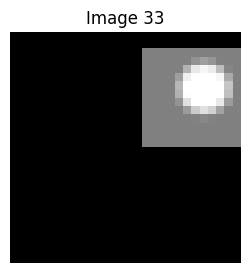

-1.0 1.0
---
-1.0 1.0


In [53]:
from utils.base_utils import t2n, to_01

"""select an image from cis dataset"""
img_idx = 33
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.imshow(target_img, cmap='gray', vmin=-1, vmax=1)
ax.axis('off')
ax.set_title(f"Image {img_idx}")
plt.show()

print(train_dataset[img_idx].min().item(), train_dataset[img_idx].max().item())
print('---')
print(target_img.min(), target_img.max())

In [54]:
config.time_channels

28

In [55]:
"""generate images from sami_inference"""
target_img = train_dataset[img_idx].unsqueeze(0).to(device)
print(target_img.shape)
sami_inference.conditional_sample(N=4, target_image_input=target_img)
gen_img = sami_inference.x_t
print(gen_img.shape)
print(gen_img.min(), gen_img.max())

torch.Size([1, 1, 28, 28])
torch.Size([4, 1, 28, 28])
tensor(-1.0239, device='cuda:0', grad_fn=<MinBackward1>) tensor(0.9868, device='cuda:0', grad_fn=<MaxBackward1>)


(28, 28, 1)
(4, 28, 28, 1)
-0.011935592 0.99340194


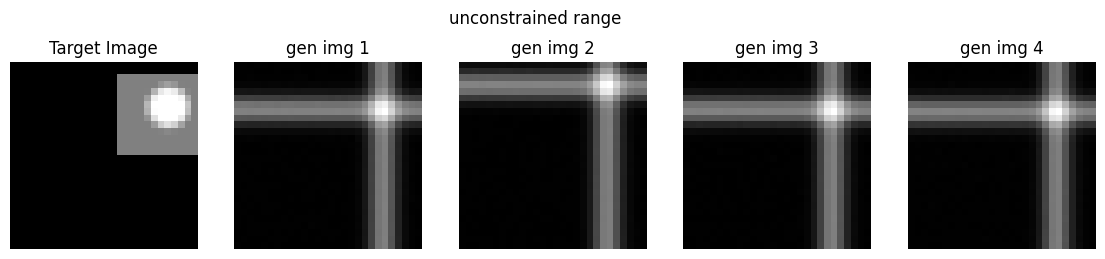

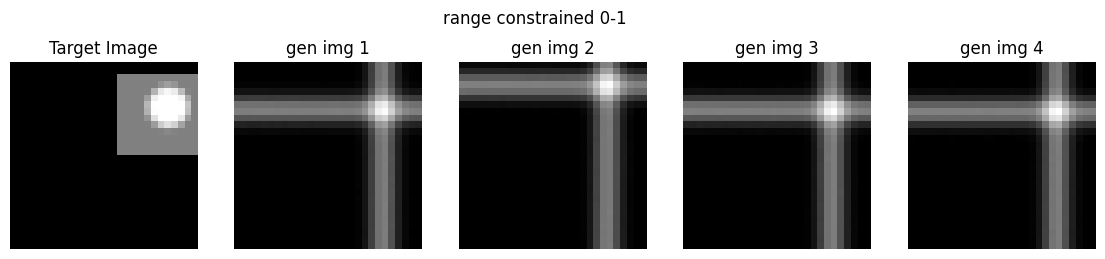

In [56]:
# figure
target_img = t2n(train_dataset[img_idx])
target_img = np.transpose(target_img, (1,2,0))
target_img = to_01(target_img)
print(target_img.shape)

gen_img_np = t2n(gen_img)
gen_img_np = np.transpose(gen_img_np, (0,2,3,1))
gen_img_np = to_01(gen_img_np)
print(gen_img_np.shape)
print(gen_img_np.min(), gen_img_np.max())


fig, ax = plt.subplots(1,5, figsize=(14,3))
ax[0].imshow(target_img, vmin=0, vmax=1, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Target Image')
for i in range(1,5):
    # ax[i].imshow(gen_img_np[i-1], vmin=0, vmax=1, cmap='gray')
    ax[i].imshow(gen_img_np[i-1], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'gen img {i}')
fig.suptitle('unconstrained range')
plt.show()

fig, ax = plt.subplots(1,5, figsize=(14,3))
ax[0].imshow(target_img, vmin=0, vmax=1, cmap='gray')
ax[0].axis('off')
ax[0].set_title('Target Image')
for i in range(1,5):
    ax[i].imshow(gen_img_np[i-1], vmin=0, vmax=1, cmap='gray')
    # ax[i].imshow(gen_img_np[i-1], cmap='gray')
    ax[i].axis('off')
    ax[i].set_title(f'gen img {i}')
fig.suptitle('range constrained 0-1')
# fig.tight_layout()
plt.show()
# ax[1].axis('off')
# ax[1].set_title('Generated Image')

[ 0 10 20 30 40 50 60 70 80 90 99]


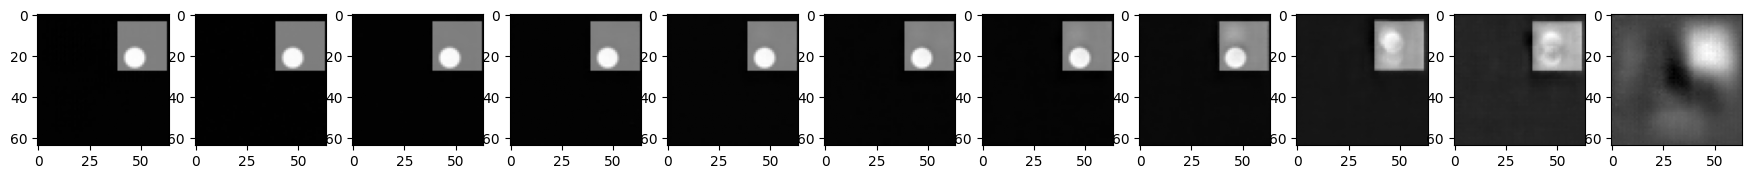

In [10]:
x0_estimates = sami_inference.x0_estimates
t_vals = np.linspace(0, config.num_timesteps, 11)
t_vals[-1] = config.num_timesteps-1
t_vals = t_vals.astype(int)
print(t_vals)

fig, ax = plt.subplots(1,11, figsize=(22,2))
for i, t in enumerate(t_vals):
    ax[i].imshow(x0_estimates[t, 0, 0].cpu().numpy(), cmap='gray')


In [11]:
for i, t in enumerate(t_vals):
    print(x0_estimates[t].min(), x0_estimates.max())

tensor(-1.0797) tensor(1.1362)
tensor(-1.0138) tensor(1.1362)
tensor(-1.0184) tensor(1.1362)
tensor(-1.0255) tensor(1.1362)
tensor(-1.0664) tensor(1.1362)
tensor(-1.0521) tensor(1.1362)
tensor(-1.0702) tensor(1.1362)
tensor(-1.1263) tensor(1.1362)
tensor(-1.1975) tensor(1.1362)
tensor(-1.2784) tensor(1.1362)
tensor(-1.5860) tensor(1.1362)


# add noise and denoise

torch.Size([1, 1, 64, 64])
torch.Size([1, 1, 64, 64])
tensor(-1.0279, device='cuda:0') tensor(1.1628, device='cuda:0')
tensor(0.0009, device='cuda:0')
tensor(-1.0279, device='cuda:0') tensor(1.1628, device='cuda:0')


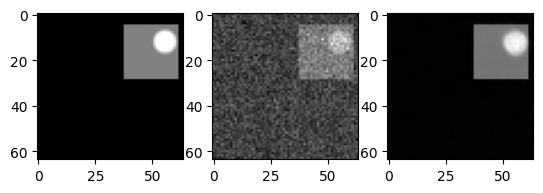

In [12]:
"""generate images from diva_inference"""
target_img = train_dataset[img_idx].unsqueeze(0).to(device)
print(target_img.shape)

x0_hat, noisy_x, pred_epsilon_guided = sami_inference.add_noise_and_denoise(
    target_image_input=target_img, t=10, x_t=None)

print(x0_hat.shape)
print(x0_hat.min(), x0_hat.max())

fig, ax = plt.subplots(1, 3)
ax[0].imshow(target_img.cpu().squeeze(), cmap="grey")
ax[1].imshow(noisy_x.cpu().squeeze(), cmap="grey")
ax[2].imshow(x0_hat.cpu().squeeze(), cmap="grey")

mse = F.mse_loss(target_img, x0_hat)
print(mse)

print(x0_hat.min(), x0_hat.max())

torch.Size([1, 1, 64, 64])
tensor(-1., device='cuda:0')
[10 20 30 40 50 60 70 80 90 99]
linear_in_alpha_bar
torch.Size([1, 1, 64, 64])
tensor(-1.5113, device='cuda:0') tensor(0.6208, device='cuda:0')


[Text(0, 0.5, 'Denoised')]

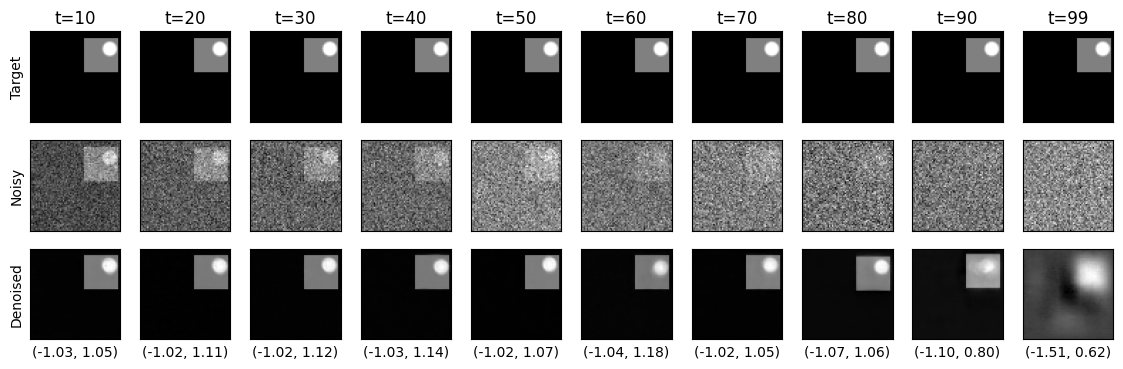

In [14]:
"""generate images from diva_inference"""
target_img = train_dataset[img_idx].unsqueeze(0).to(device)
print(target_img.shape)
print(target_img.min())

t_vals = np.linspace(10, config.num_timesteps, config.num_timesteps//10)
t_vals[-1] = config.num_timesteps-1
t_vals = t_vals.astype(int)
print(t_vals)

one_shot_denoising_estimates = torch.empty(len(t_vals), *target_img.shape)
noisy_xs = torch.empty(len(t_vals), *target_img.shape)

for i, t in enumerate(t_vals):
    x0_hat, noisy_x, pred_epsilon_guided = sami_inference.add_noise_and_denoise(
        target_image_input=target_img, t=t, x_t=None)
    noisy_xs[i] = noisy_x.cpu().squeeze()
    one_shot_denoising_estimates[i] = x0_hat.cpu().squeeze()
    
print(config.noise_schedule)
print(x0_hat.shape)
print(x0_hat.min(), x0_hat.max())

fig, ax = plt.subplots(3, len(t_vals), figsize=(14, 4))
for i in range(len(t_vals)):
    ax[0, i].imshow(target_img.cpu().squeeze(), cmap="grey")
    ax[0,i].set(title=f"t={t_vals[i]}")
    noisy_x = noisy_xs[i].cpu().squeeze()
    ax[1,i].imshow(noisy_x, cmap="grey")
    x0_hat = one_shot_denoising_estimates[i].squeeze()
    ax[2,i].imshow(x0_hat, cmap="grey")
    ax[2,i].set(xlabel=f"({x0_hat.min():.2f}, {x0_hat.max():.2f})")

for i in range(len(t_vals)):
    ax[0,i].set(xticks=[], yticks=[])
    ax[1,i].set(xticks=[], yticks=[])
    ax[2,i].set(xticks=[], yticks=[])

ax[0,0].set(ylabel="Target")
ax[1,0].set(ylabel="Noisy")
ax[2,0].set(ylabel="Denoised")

# mse = F.mse_loss(target_img, x0_hat)
# print(mse)

# print(x0_hat.min(), x0_hat.max())

In [15]:
print(target_img.squeeze().min())
print(one_shot_denoising_estimates[0].squeeze().numpy().max())

tensor(-1., device='cuda:0')
1.0531211


/tmp/ipykernel_1085247/562467733.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mse = F.mse_loss(one_shot_denoising_estimates[i].squeeze().cpu(), torch.tensor(target_img.squeeze()).cpu())


Text(0.5, 0, 't')

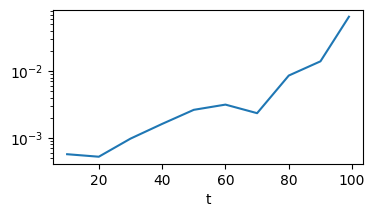

In [16]:
# plot the mse of the one shot denoising as a function of t
mse_values = []
for i, t in enumerate(t_vals):
    mse = F.mse_loss(one_shot_denoising_estimates[i].squeeze().cpu(), torch.tensor(target_img.squeeze()).cpu())
    mse_values.append(mse)

fig, ax = plt.subplots(1, 1, figsize=(4, 2))
ax.plot(t_vals, mse_values)
ax.set_yscale('log')
ax.set_xlabel('t')

## noise up to t and then iterative conditional sampling

torch.Size([1, 1, 64, 64])
tensor(-3.6119, device='cuda:0', grad_fn=<MinBackward1>) tensor(4.9468, device='cuda:0', grad_fn=<MaxBackward1>)
torch.Size([13, 1, 1, 64, 64])


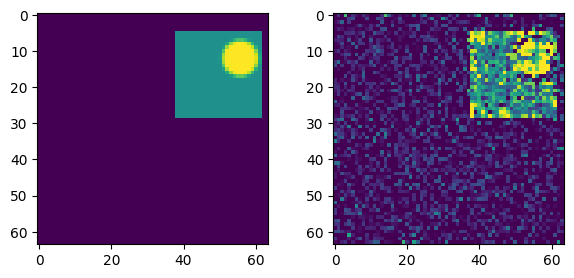

In [19]:
t = 13
target_img = train_dataset[img_idx].unsqueeze(0).to(device)
sami_inference.add_noise_and_iteratively_denoise(
    target_image_input=target_img, t=t)

gen_img = sami_inference.x_t
print(gen_img.shape)
print(gen_img.min(), gen_img.max())

gen_img_chain = sami_inference.x0_estimates
print(gen_img_chain.shape)

from utils.plotting import make_presentable
target_img_show = make_presentable(target_img)
gen_img_show = make_presentable(gen_img)

fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].imshow(target_img_show)
ax[1].imshow(gen_img_show)

## latent marginals

/tmp/ipykernel_1082399/1557032302.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  gt_square_positions[i] = square_targets[i]
/tmp/ipykernel_1082399/1557032302.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  gt_circle_positions[i] = circle_targets[i]


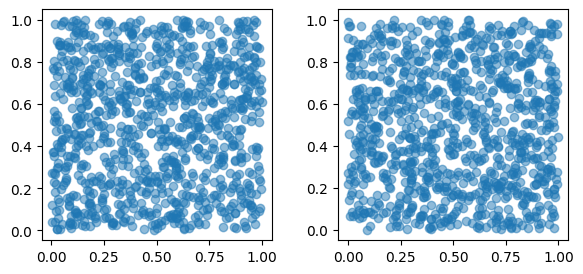

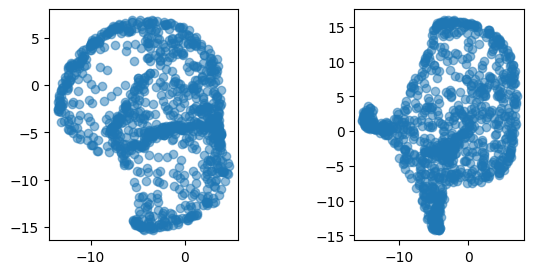

In [26]:
# encoder values
num_samples = 1000
latents = np.empty((num_samples, 4))
gt_square_positions = np.empty((num_samples, 2))
gt_circle_positions = np.empty((num_samples, 2))

for i in range(num_samples):
    target_img = train_dataset[i].unsqueeze(0).to(device)
    # print(target_img.shape)
    z = sami_inference.infnet(target_img)[0].squeeze().detach().cpu().numpy()
    # print(z.shape)
    gt_square_positions[i] = square_targets[i]
    gt_circle_positions[i] = circle_targets[i]
    latents[i] = z

fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].scatter(*gt_square_positions.T, alpha=0.5)
ax[0].set_aspect('equal')
ax[1].scatter(*gt_circle_positions.T, alpha=0.5)
ax[1].set_aspect('equal')

fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].scatter(*latents[:, :2].T, alpha=0.5)
ax[0].set_aspect('equal')
ax[1].scatter(*latents[:, 1:3].T, alpha=0.5)
ax[1].set_aspect('equal')

plt.show()

# bottom